# **Nama : Ardan Ferdiansah**

# **NIM: 3.34.23.3.03**

# **Kelas : IK 3D**

## Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


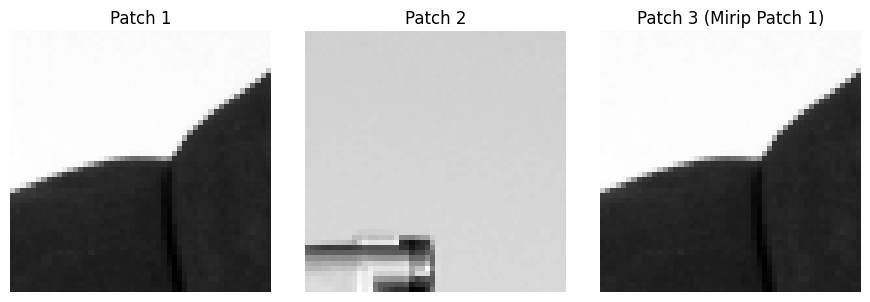

In [ ]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt


# 1. Buat dua patch citra sederhana
image = img_as_float(data.camera())

patch1 = image[100:150, 100:150]

patch2 = image[100:150, 300:350]  # Patch berbeda

patch3 = patch1 + 0.1  # Patch mirip dengan sedikit perubahan

patch3 = np.clip(patch3, 0, 1)


# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()

vec2 = patch2.flatten()

vec3 = patch3.flatten()


# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)

dist_l2_13 = distance.euclidean(vec1, vec3)


# 4. Hitung Jarak Manhattan (L1)
dist_l1_12 = distance.cityblock(vec1, vec2)

dist_l1_13 = distance.cityblock(vec1, vec3)


# 5. Tampilkan hasil
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")

print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")

print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")

print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")


# 6. Visualisasi patch
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Praktikum 2. Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity Image 1 dan Image 2: 0.8156
Cosine Similarity Image 1 dan Image 3: 1.0000
Cosine Similarity Image 1 dan Image 4: 1.0000


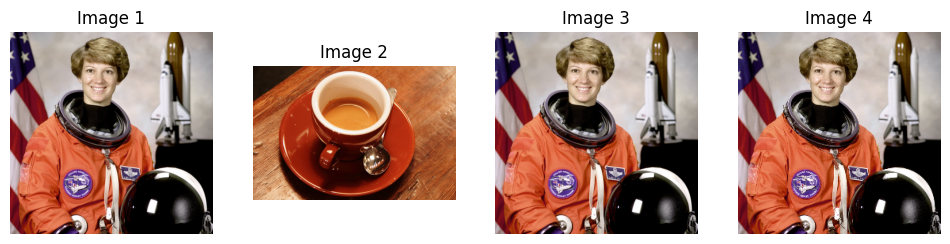

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_ubyte
from scipy.spatial import distance


# Fungsi menghitung histogram RGB
def calculate_rgb_histogram(image, bins=16):

    img_uint8 = img_as_ubyte(image)

    hist_r, _ = np.histogram(
        img_uint8[:, :, 0].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_g, _ = np.histogram(
        img_uint8[:, :, 1].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_b, _ = np.histogram(
        img_uint8[:, :, 2].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Gabungkan histogram RGB
    hist_combined = np.concatenate(
        (hist_r, hist_g, hist_b)
    )

    # Normalisasi
    hist_combined = (
        hist_combined.astype(float)
        / np.sum(hist_combined)
    )

    return hist_combined


# 1. Muat citra
try:

    image1 = data.astronaut()

    image2 = data.coffee()

    image3 = data.astronaut()

    image4 = image1[::2, ::2, :]

except Exception as e:

    print(f"Gagal memuat data: {e}")

    image1 = np.random.rand(100, 100, 3)

    image2 = np.random.rand(100, 100, 3)

    image3 = image1.copy()

    image4 = image1[::2, ::2, :]


# 2. Hitung histogram
hist1 = calculate_rgb_histogram(image1)

hist2 = calculate_rgb_histogram(image2)

hist3 = calculate_rgb_histogram(image3)

hist4 = calculate_rgb_histogram(image4)


# 3. Hitung Cosine Similarity
sim_12 = 1 - distance.cosine(hist1, hist2)

sim_13 = 1 - distance.cosine(hist1, hist3)

sim_14 = 1 - distance.cosine(hist1, hist4)


# 4. Tampilkan hasil
print(f"Cosine Similarity Image 1 dan Image 2: {sim_12:.4f}")

print(f"Cosine Similarity Image 1 dan Image 3: {sim_13:.4f}")

print(f"Cosine Similarity Image 1 dan Image 4: {sim_14:.4f}")


# 5. Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(image1)
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4')
axes[3].axis('off')

plt.show()

## Praktikum 3. Menghitung Structural Similarity Index (SSIM)

SSIM Same: 1.0000
SSIM Noisy: 0.2956
SSIM Contrast: 0.9651
SSIM Blurred: 0.8027


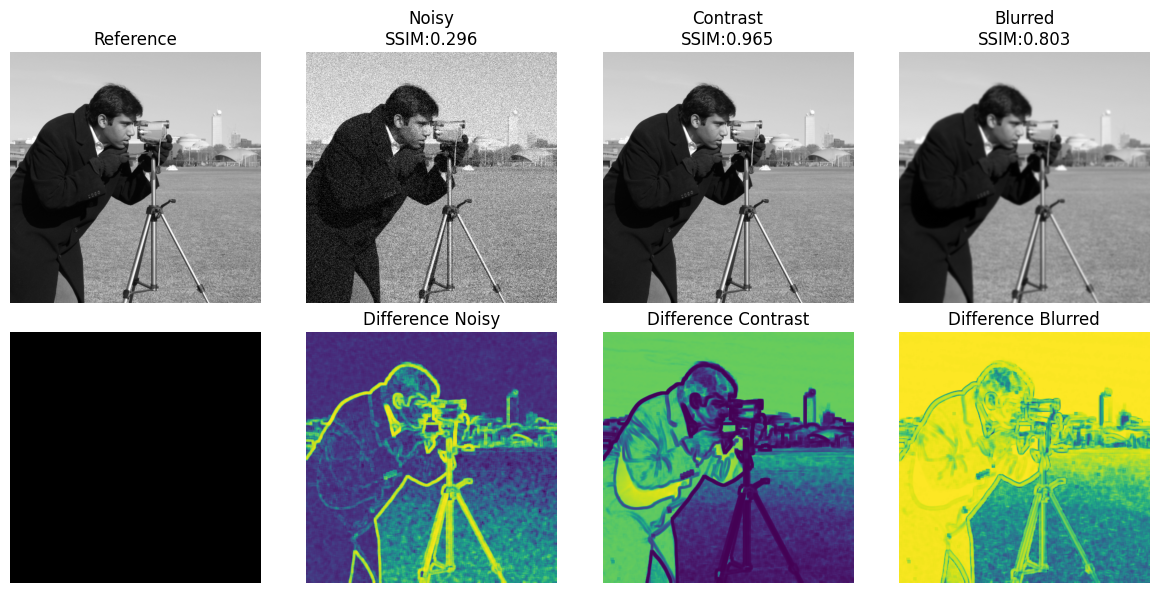

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian


# 1. Muat citra referensi
image_ref = img_as_float(data.camera())


# 2. Buat citra terdistorsi
image_same = image_ref.copy()

image_noisy = random_noise(
    image_ref,
    mode='gaussian',
    var=0.01
)

image_contrast = np.clip(
    image_ref * 0.8,
    0,
    1
)

image_blurred = gaussian(
    image_ref,
    sigma=1.5,
    channel_axis=None
)


# 3. Hitung SSIM
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(
    image_ref,
    image_same,
    data_range=data_range,
    full=True
)

ssim_noisy, diff_noisy = ssim(
    image_ref,
    image_noisy,
    data_range=data_range,
    full=True
)

ssim_contrast, diff_contrast = ssim(
    image_ref,
    image_contrast,
    data_range=data_range,
    full=True
)

ssim_blurred, diff_blurred = ssim(
    image_ref,
    image_blurred,
    data_range=data_range,
    full=True
)


# 4. Tampilkan hasil
print(f"SSIM Same: {ssim_same:.4f}")

print(f"SSIM Noisy: {ssim_noisy:.4f}")

print(f"SSIM Contrast: {ssim_contrast:.4f}")

print(f"SSIM Blurred: {ssim_blurred:.4f}")


# 5. Visualisasi
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

ax = axes.ravel()

ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM:{ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM:{ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM:{ssim_blurred:.3f}')
ax[3].axis('off')

ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].axis('off')

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('Difference Noisy')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('Difference Contrast')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('Difference Blurred')
ax[7].axis('off')

plt.tight_layout()
plt.show()

Praktikum 4. Penerapan Template Matching

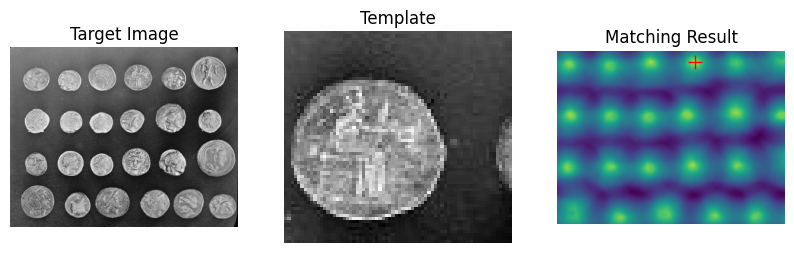

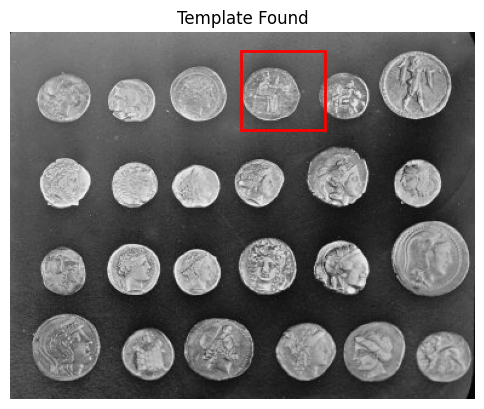

Template ditemukan di koordinat: (190, 15)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.feature import match_template


# 1. Muat citra target
image = data.coins()

# Ambil template
template = image[15:80, 190:260]


# 2. Template matching
result = match_template(image, template)


# 3. Cari lokasi terbaik
ij = np.unravel_index(
    np.argmax(result),
    result.shape
)

x, y = ij[::-1]


# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result')
ax[2].set_axis_off()

ax[2].plot(x, y, 'r+', markersize=10)


# Visualisasi lokasi template
fig2, ax_main = plt.subplots(figsize=(6, 6))

ax_main.imshow(image, cmap='gray')

ax_main.set_title('Template Found')

ax_main.set_axis_off()

h, w = template.shape

rect = plt.Rectangle(
    (x, y),
    w,
    h,
    edgecolor='r',
    facecolor='none',
    lw=2
)

ax_main.add_patch(rect)

plt.show()

print(f"Template ditemukan di koordinat: ({x}, {y})")

## Praktikum 5. Simulasi CBIR Sederhana

Memproses database...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval:
Rank 1: chelsea (Distance:0.000)
Rank 2: coins (Distance:0.288)
Rank 3: coffee (Distance:0.359)
Rank 4: astronaut (Distance:0.461)
Rank 5: camera (Distance:0.602)


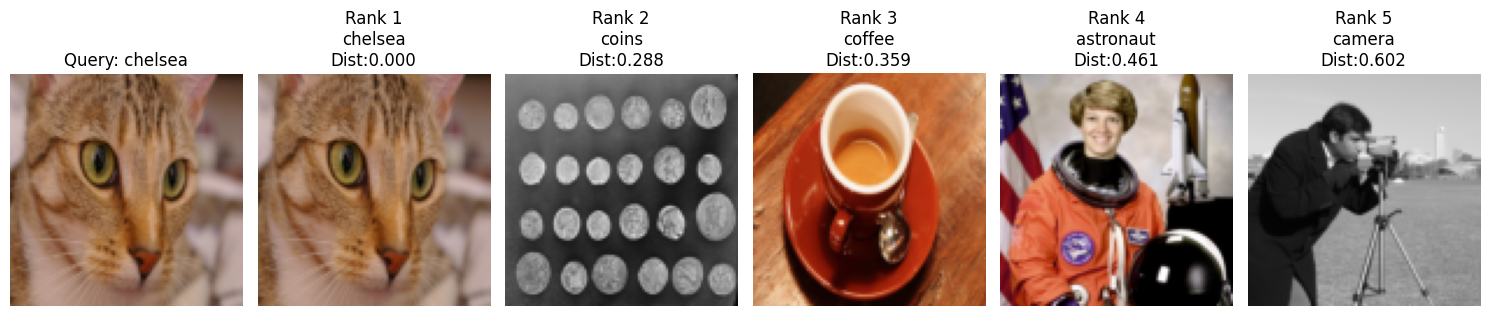

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance


# Fungsi histogram RGB
def calculate_rgb_histogram(image, bins=16):

    if image.dtype == float:
        image = img_as_ubyte(image)

    hist_r, _ = np.histogram(
        image[:, :, 0].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_g, _ = np.histogram(
        image[:, :, 1].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_b, _ = np.histogram(
        image[:, :, 2].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_combined = np.concatenate(
        (hist_r, hist_g, hist_b)
    )

    hist_sum = np.sum(hist_combined)

    if hist_sum > 0:
        hist_combined = (
            hist_combined.astype(float)
            / hist_sum
        )

    else:
        hist_combined = hist_combined.astype(float)

    return hist_combined


# 1. Database citra
image_db_names = [
    "astronaut",
    "camera",
    "coffee",
    "coins",
    "chelsea"
]

database_images = []

database_hists = []

print("Memproses database...")


for name in image_db_names:

    try:

        img = getattr(data, name)()

        if img.ndim == 2:
            img = color.gray2rgb(img)

        img_resized = transform.resize(
            img,
            (100, 100),
            anti_aliasing=True
        )

        database_images.append(img_resized)

        database_hists.append(
            calculate_rgb_histogram(img_resized)
        )

        print(f"- {name} diproses.")

    except Exception as e:

        print(f"Error memproses {name}: {e}")


# 2. Query image
query_image_name = "chelsea"

query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]

query_hist = database_hists[query_index]


# 3. Hitung jarak cosine
distances = []

for hist in database_hists:

    dist = distance.cosine(
        query_hist,
        hist
    )

    distances.append(dist)


# 4. Sorting hasil
sorted_indices = np.argsort(distances)


# 5. Visualisasi hasil retrieval
num_results_to_show = len(database_images)

fig, axes = plt.subplots(
    1,
    num_results_to_show + 1,
    figsize=(15, 3)
)

axes[0].imshow(query_image)

axes[0].set_title(f"Query: {query_image_name}")

axes[0].axis('off')

print("\nHasil Retrieval:")


for i, idx in enumerate(sorted_indices):

    img_rank = i + 1

    ax = axes[img_rank]

    ax.imshow(database_images[idx])

    ax.set_title(
        f"Rank {img_rank}\n"
        f"{image_db_names[idx]}\n"
        f"Dist:{distances[idx]:.3f}"
    )

    ax.axis('off')

    print(
        f"Rank {img_rank}: "
        f"{image_db_names[idx]} "
        f"(Distance:{distances[idx]:.3f})"
    )

plt.tight_layout()
plt.show()

## Penugasan 3. Fitur Berbeda untuk CBIR

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval:
Rank 1: chelsea (Distance:0.000)
Rank 2: astronaut (Distance:0.050)
Rank 3: coffee (Distance:0.176)
Rank 4: camera (Distance:0.194)
Rank 5: coins (Distance:0.211)


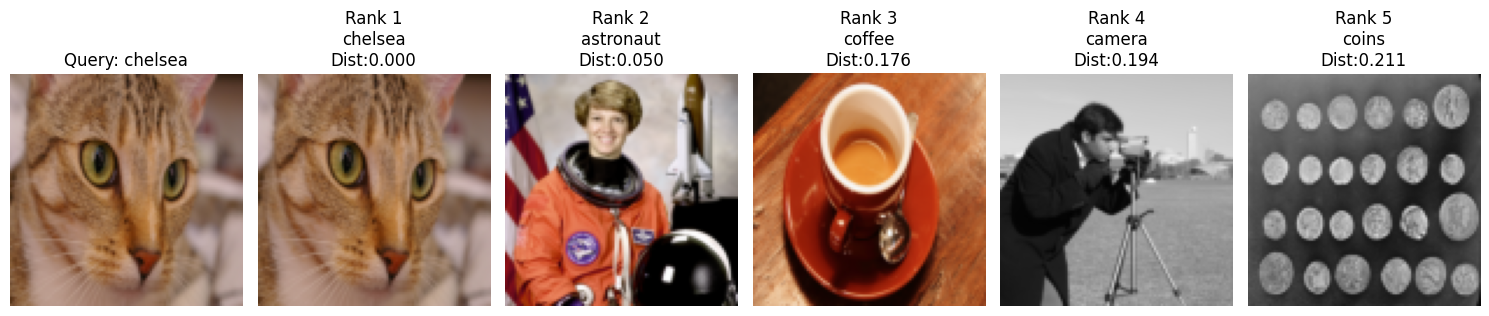

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color, transform
from scipy.spatial import distance


# Fungsi menghitung mean RGB
def calculate_mean_rgb(image):

    # Jika grayscale ubah ke RGB
    if image.ndim == 2:
        image = color.gray2rgb(image)

    mean_r = np.mean(image[:, :, 0])

    mean_g = np.mean(image[:, :, 1])

    mean_b = np.mean(image[:, :, 2])

    return np.array([mean_r, mean_g, mean_b])


# 1. Siapkan database citra
image_db_names = [
    "astronaut",
    "camera",
    "coffee",
    "coins",
    "chelsea"
]

database_images = []

database_features = []

print("Memproses database citra...")


for name in image_db_names:

    try:

        img = getattr(data, name)()

        # Jika grayscale ubah ke RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize citra
        img_resized = transform.resize(
            img,
            (100, 100),
            anti_aliasing=True
        )

        database_images.append(img_resized)

        # Hitung fitur mean RGB
        feature = calculate_mean_rgb(img_resized)

        database_features.append(feature)

        print(f"- {name} diproses.")

    except Exception as e:

        print(f"Error memproses {name}: {e}")


# 2. Pilih query image
query_image_name = "chelsea"

query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]

query_feature = database_features[query_index]


# 3. Hitung Euclidean Distance
distances = []

for feature in database_features:

    dist = distance.euclidean(
        query_feature,
        feature
    )

    distances.append(dist)


# 4. Urutkan berdasarkan jarak
sorted_indices = np.argsort(distances)


# 5. Visualisasi hasil retrieval
num_results_to_show = len(database_images)

fig, axes = plt.subplots(
    1,
    num_results_to_show + 1,
    figsize=(15, 3)
)

# Query image
axes[0].imshow(query_image)

axes[0].set_title(f"Query: {query_image_name}")

axes[0].axis('off')

print("\nHasil Retrieval:")


for i, idx in enumerate(sorted_indices):

    img_rank = i + 1

    ax = axes[img_rank]

    ax.imshow(database_images[idx])

    ax.set_title(
        f"Rank {img_rank}\n"
        f"{image_db_names[idx]}\n"
        f"Dist:{distances[idx]:.3f}"
    )

    ax.axis('off')

    print(
        f"Rank {img_rank}: "
        f"{image_db_names[idx]} "
        f"(Distance:{distances[idx]:.3f})"
    )

plt.tight_layout()
plt.show()

## Penugasan 4. Template Matching Invariant

Template asli ditemukan di: (190, 15)
Template rotasi ditemukan di: (181, 151)
Template resize ditemukan di: (225, 66)


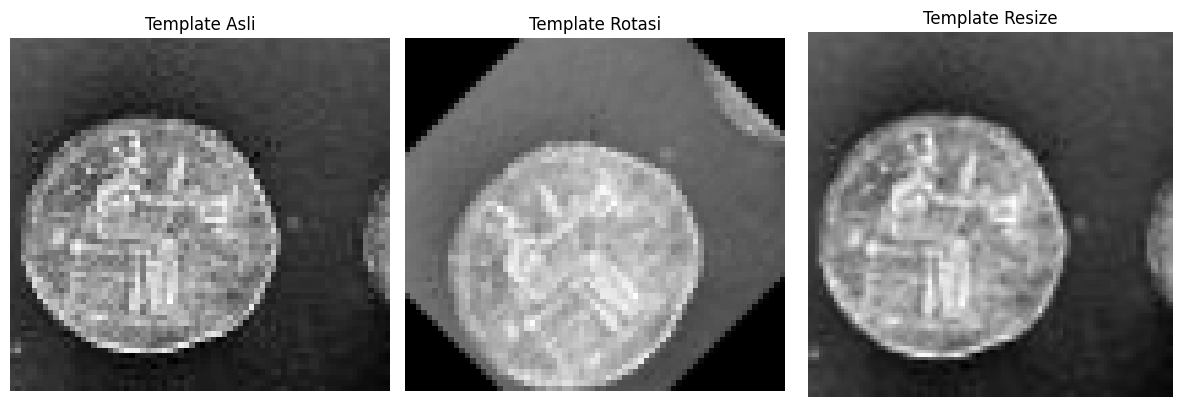

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, resize


# 1. Muat citra target
image = data.coins()

# Ambil template
template = image[15:80, 190:260]


# ==================================================
# Template Matching Normal
# ==================================================

result = match_template(image, template)

ij = np.unravel_index(
    np.argmax(result),
    result.shape
)

x, y = ij[::-1]

print(f"Template asli ditemukan di: ({x}, {y})")


# ==================================================
# Template Rotasi
# ==================================================

template_rotated = rotate(
    template,
    angle=45
)

result_rot = match_template(
    image,
    template_rotated
)

ij_rot = np.unravel_index(
    np.argmax(result_rot),
    result_rot.shape
)

x_rot, y_rot = ij_rot[::-1]

print(f"Template rotasi ditemukan di: ({x_rot}, {y_rot})")


# ==================================================
# Template Resize
# ==================================================

template_scaled = resize(
    template,
    (100, 100)
)

result_scale = match_template(
    image,
    template_scaled
)

ij_scale = np.unravel_index(
    np.argmax(result_scale),
    result_scale.shape
)

x_scale, y_scale = ij_scale[::-1]

print(f"Template resize ditemukan di: ({x_scale}, {y_scale})")


# ==================================================
# Visualisasi
# ==================================================

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(template, cmap='gray')
ax[0].set_title('Template Asli')
ax[0].axis('off')

ax[1].imshow(template_rotated, cmap='gray')
ax[1].set_title('Template Rotasi')
ax[1].axis('off')

ax[2].imshow(template_scaled, cmap='gray')
ax[2].set_title('Template Resize')
ax[2].axis('off')

plt.tight_layout()
plt.show()